# Employee Attrition Prediction with Random Forest

## Problem Overview
This notebook builds a **Random Forest classifier** to predict whether an employee is likely to leave the company (`Attrition = 1`) or stay (`Attrition = 0`).

## Random Forest Algorithm
Random Forest is an **ensemble learning algorithm** that combines many decision trees instead of using only one tree.

### How it works
- The algorithm creates many decision trees from different random samples of the training data.
- Each tree learns a slightly different pattern from the data.
- For classification, every tree gives a vote.
- The final prediction is the class that gets the **most votes**.

### Why it is useful for this project
- It works well for **tabular employee data**.
- It can learn **non-linear relationships** between employee features and attrition.
- It reduces overfitting better than a single decision tree.
- It provides **feature importance**, which helps explain which factors influence attrition more strongly.

## Evaluation Metric Selection
For employee attrition prediction, the **main evaluation metric** in this notebook is **F1 score**.

### Main metric: F1 score
F1 score is used as the main metric because it gives a balanced view of:
- **Precision**: how many predicted attrition cases are actually correct
- **Recall**: how many real attrition cases the model successfully finds

This is important because attrition prediction usually has **class imbalance**, where employees who stay are much more common than employees who leave.

### Supporting metrics
The notebook also reports other metrics to give a fuller evaluation:
- **Accuracy**: overall percentage of correct predictions
- **Precision**: reliability of positive attrition predictions
- **Recall**: ability to detect actual attrition cases
- **ROC-AUC**: overall class-separation ability across thresholds
- **PR-AUC**: useful when the positive class is less common

## Notebook Structure
1. Import libraries
2. Load SMOTE-balanced training data and original test data
3. Explore data distributions and feature relationships
4. Train a baseline Random Forest model
5. Tune the model using GridSearchCV
6. Evaluate the tuned model
7. Tune the prediction threshold
8. Save the final model and CSV outputs in organized folders


## Step 1 — Import Libraries

This section imports all Python libraries used for data handling, modeling, evaluation, plotting, and saving files.


In [27]:
# Data handling
import os
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Model saving
import joblib

# Machine learning model
from sklearn.ensemble import RandomForestClassifier

# Model selection tools
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries imported successfully')
print('Random state:', RANDOM_STATE)


# Better plot appearance for the notebook
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11


Libraries imported successfully
Random state: 42


## Step 2 — Load Data

These files come from the preprocessing notebook.

- `X_train_smote.csv`: training features after SMOTE
- `y_train_smote.csv`: training labels after SMOTE
- `X_test.csv`: original test features
- `y_test.csv`: original test labels

> **Important:** SMOTE is used only on the training set. The test set stays unchanged so model evaluation is more realistic.


In [28]:
# Load the balanced training set
X_train = pd.read_csv('../../outputs/X_train_smote.csv')
y_train = pd.read_csv('../../outputs/y_train_smote.csv').values.ravel()

# Load the original test set
X_test = pd.read_csv('../../outputs/X_test.csv')
y_test = pd.read_csv('../../outputs/y_test.csv').values.ravel()

print('Data loaded successfully')
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

print('Training class distribution (after SMOTE):')
print(pd.Series(y_train).value_counts().rename({0: 'No Attrition', 1: 'Attrition'}))

print('Test class distribution (original):')
print(pd.Series(y_test).value_counts().rename({0: 'No Attrition', 1: 'Attrition'}))

Data loaded successfully
X_train shape: (1972, 44)
y_train shape: (1972,)
X_test shape : (294, 44)
y_test shape : (294,)
Training class distribution (after SMOTE):
No Attrition    986
Attrition       986
Name: count, dtype: int64
Test class distribution (original):
No Attrition    247
Attrition        47
Name: count, dtype: int64


## Step 3 — Create Output Folders

To keep the project clean, outputs are saved into separate folders.

- `models/` for trained model files
- `predictions/` for prediction-related CSV files
- `metrics/` for metric tables and feature importance CSV files
- `plots/` for saved charts


In [29]:
# Create organized output folders
OUTPUT_DIR = '../../outputs'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
METRICS_DIR = os.path.join(OUTPUT_DIR, 'metrics')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')

for folder in [MODELS_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Output folders are ready:')
print(' -', MODELS_DIR)
print(' -', PREDICTIONS_DIR)
print(' -', METRICS_DIR)
print(' -', PLOTS_DIR)


Output folders are ready:
 - ../../outputs\models
 - ../../outputs\predictions
 - ../../outputs\metrics
 - ../../outputs\plots


## Step 4 — Dataset Distribution, Variance, and Relationship Charts

Before training the model, it is useful to look at the data.

This section answers simple questions such as:
- Which numeric features vary the most?
- Which features are strongly related to each other?
- Do training and test distributions look similar?

These checks help us understand the data before modeling.


Top 10 features by variance:
           Feature     Variance
       MonthlyRate 5.048418e+07
     MonthlyIncome 1.832952e+07
         DailyRate 1.457776e+05
        HourlyRate 3.559406e+02
               Age 8.081538e+01
  DistanceFromHome 5.729388e+01
 TotalWorkingYears 5.478533e+01
    YearsAtCompany 3.109401e+01
 PercentSalaryHike 1.211127e+01
YearsInCurrentRole 1.115801e+01


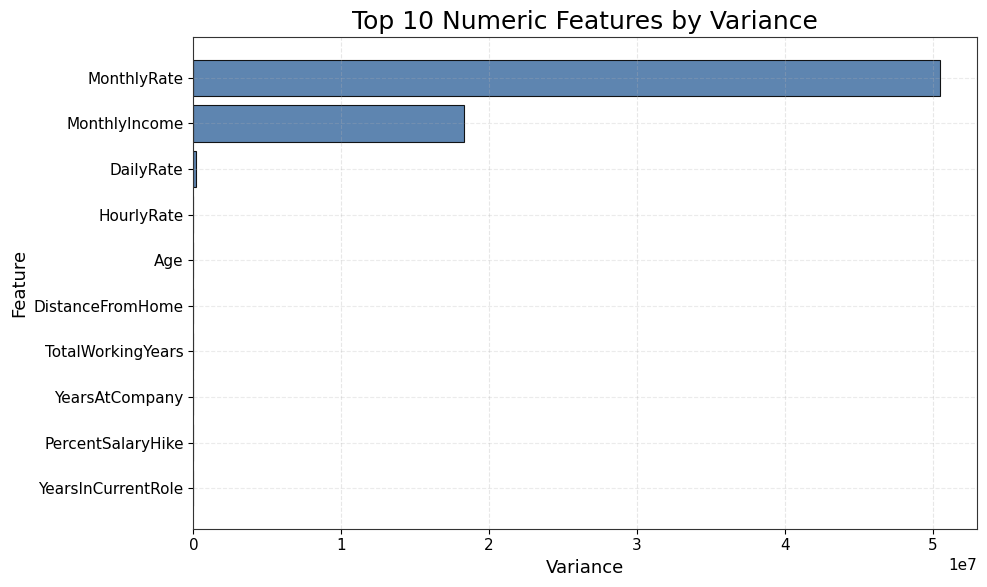

In [30]:
# Keep only numeric columns for variance and correlation analysis
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Calculate feature variance and rank from highest to lowest
variance_df = (
    X_train[numeric_columns]
    .var()
    .sort_values(ascending=False)
    .reset_index()
)
variance_df.columns = ['Feature', 'Variance']

print('Top 10 features by variance:')
print(variance_df.head(10).to_string(index=False))

# Plot the top 10 variance values
top_variance = variance_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    top_variance['Feature'],
    top_variance['Variance'],
    color='#4C78A8',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)
plt.xlabel('Variance')
plt.ylabel('Feature')
plt.title('Top 10 Numeric Features by Variance')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_top_feature_variance.png'), dpi=300, bbox_inches='tight')
plt.show()


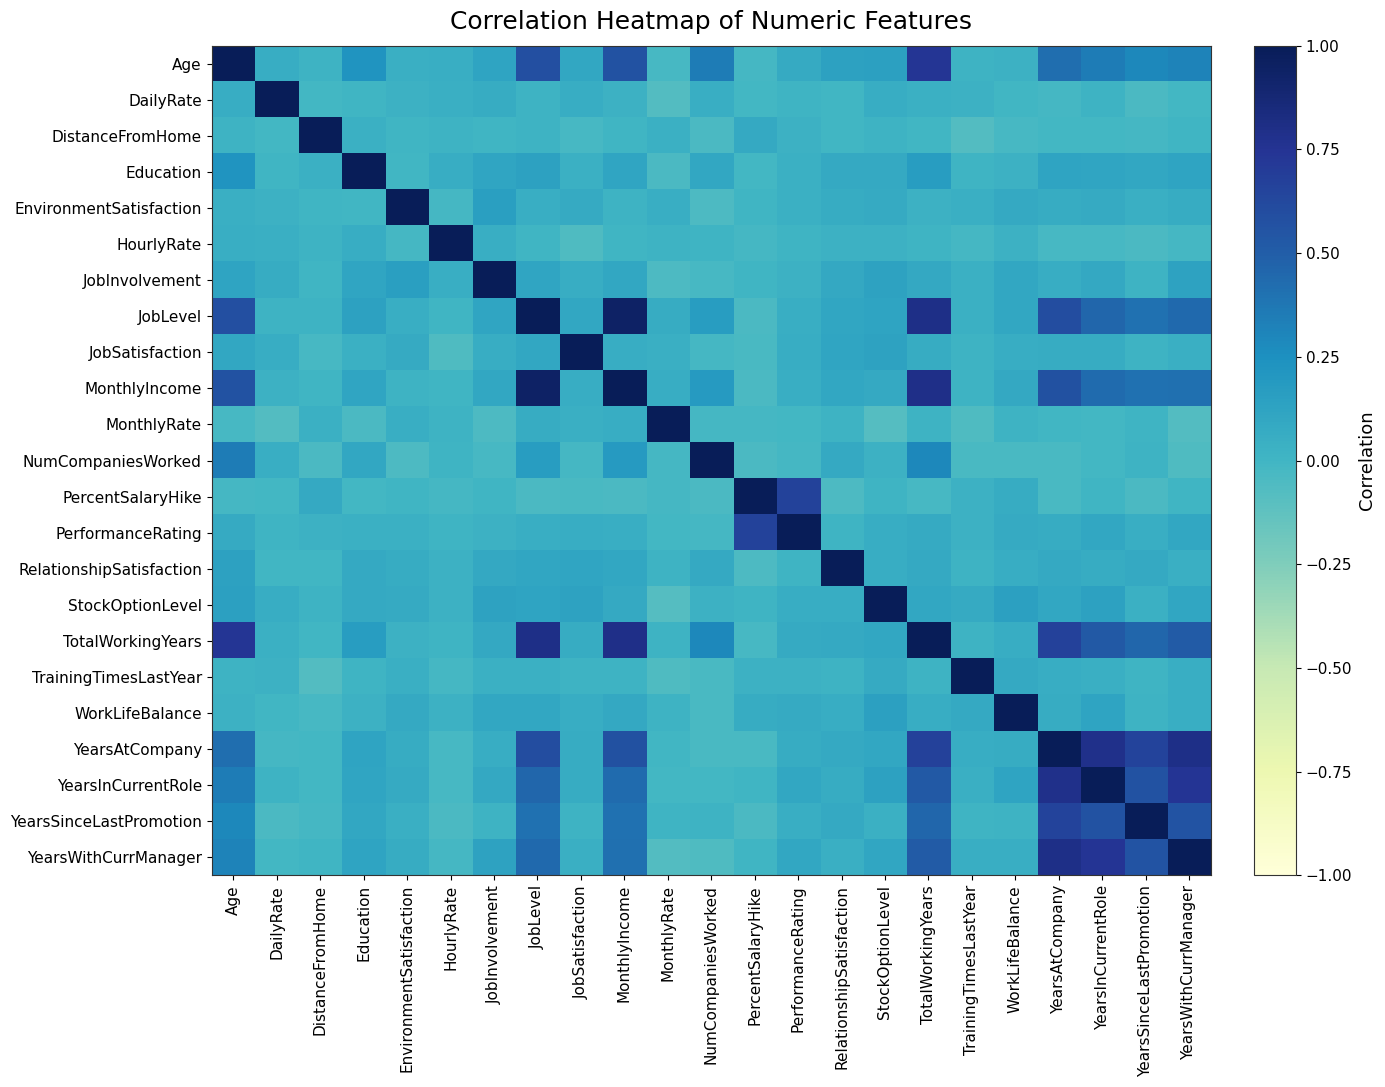

In [31]:
# Compute the correlation matrix for numeric features
correlation_matrix = X_train[numeric_columns].corr()

# Plot a cleaner and more readable correlation heatmap
plt.figure(figsize=(14, 11))
heatmap = plt.imshow(
    correlation_matrix,
    cmap='YlGnBu',
    aspect='auto',
    vmin=-1,
    vmax=1,
    interpolation='nearest'
)

cbar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns)
plt.title('Correlation Heatmap of Numeric Features', pad=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()


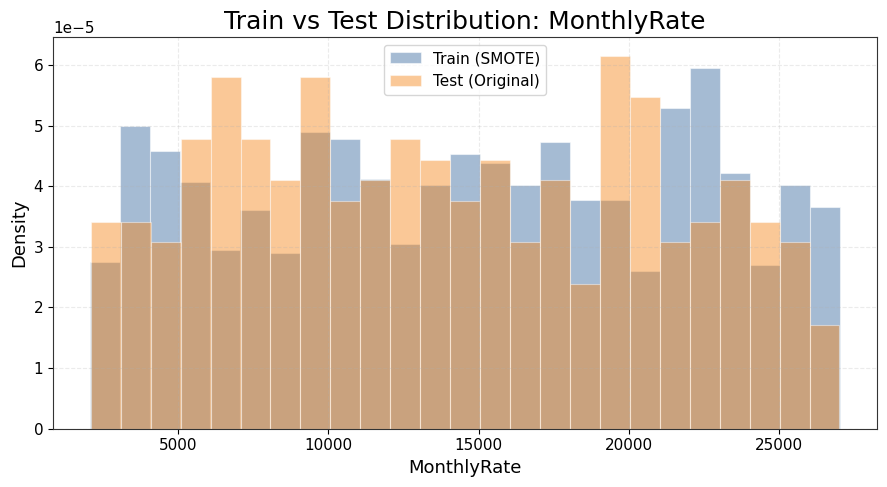

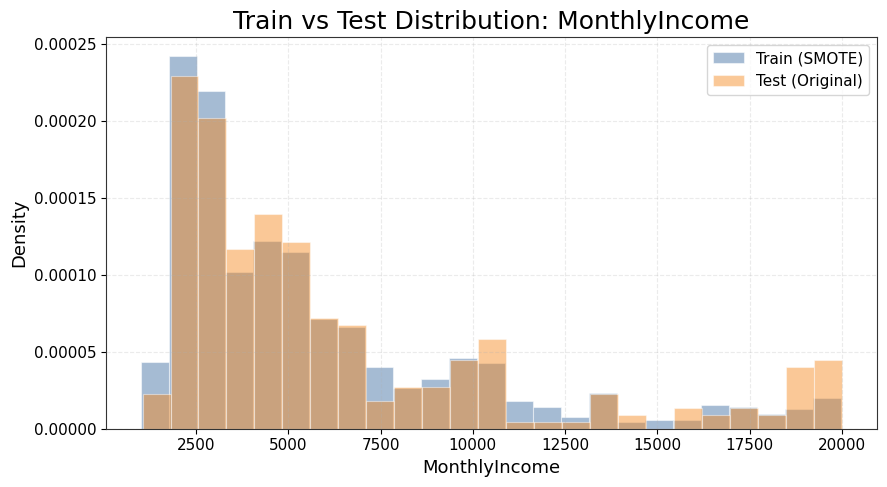

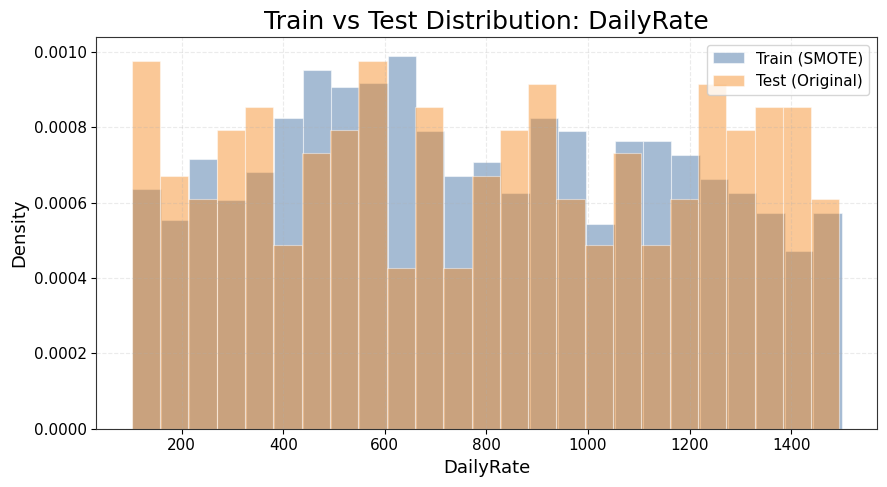

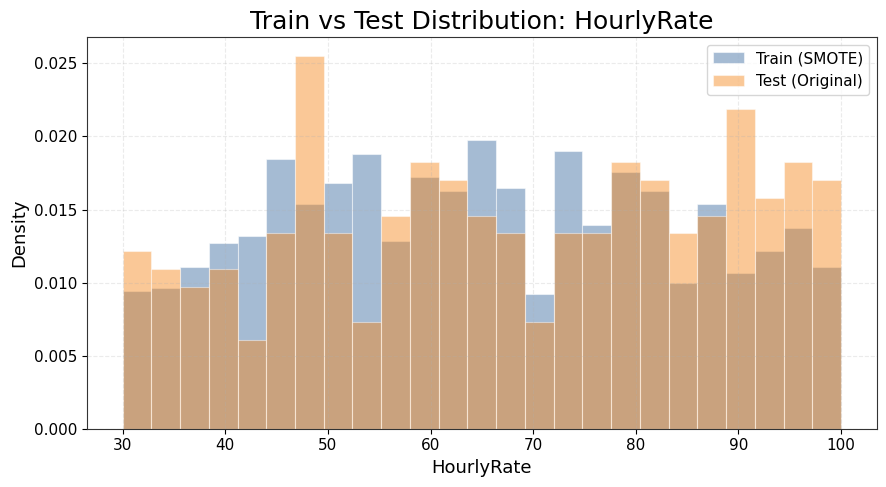

In [32]:
# Compare train and test distributions for top numeric features by variance
# We use the original test set and the SMOTE training set to see whether the shapes are reasonably similar.
top_numeric_features = variance_df.head(4)['Feature'].tolist()

for feature in top_numeric_features:
    plt.figure(figsize=(9, 5))

    plt.hist(
        X_train[feature],
        bins=25,
        density=True,
        alpha=0.50,
        label='Train (SMOTE)',
        color='#4C78A8',
        edgecolor='white',
        linewidth=0.8
    )

    plt.hist(
        X_test[feature],
        bins=25,
        density=True,
        alpha=0.45,
        label='Test (Original)',
        color='#F58518',
        edgecolor='white',
        linewidth=0.8
    )

    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'Train vs Test Distribution: {feature}')
    plt.legend(frameon=True)
    plt.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'rf_distribution_{feature}.png'), dpi=300, bbox_inches='tight')
    plt.show()


## Step 5 — Train a Baseline Model

A baseline model is a simple starting point. It helps us see whether hyperparameter tuning really improves the results.


In [33]:
# Train a default Random Forest model for comparison
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
baseline_rf.fit(X_train, y_train)

# Make baseline predictions
baseline_pred = baseline_rf.predict(X_test)
baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]

# Evaluate the baseline model
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'F1 Score': f1_score(y_test, baseline_pred, zero_division=0),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, baseline_prob),
    'PR-AUC': average_precision_score(y_test, baseline_prob)
}

print('Baseline model results:')
for metric, value in baseline_metrics.items():
    print(f'  {metric:10s}: {value:.4f}')


Baseline model results:
  Accuracy  : 0.8231
  F1 Score  : 0.2778
  Precision : 0.4000
  Recall    : 0.2128
  ROC-AUC   : 0.7383
  PR-AUC    : 0.3675


## Step 6 — Define the Hyperparameter Grid

GridSearchCV will try different parameter combinations and find the best one.

### Simple meaning of each parameter
- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum samples needed to split a node
- `min_samples_leaf`: minimum samples allowed in a leaf
- `max_features`: number of features considered at each split
- `class_weight`: gives more importance to minority class when needed


In [34]:
# Define values to test during hyperparameter tuning
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Count how many combinations will be tested
combination_count = 1
for values in param_grid.values():
    combination_count *= len(values)

print('Parameter grid created')
print('Total combinations:', combination_count)
print('Total fits with 5-fold CV:', combination_count * 5)


Parameter grid created
Total combinations: 144
Total fits with 5-fold CV: 720


## Step 7 — Create the Base Random Forest Model

This model is the starting estimator that GridSearchCV will tune.


In [35]:
# Create the base Random Forest model
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Base Random Forest model created')


Base Random Forest model created


## Step 8 — Run GridSearchCV

### Why use StratifiedKFold?
It keeps the class ratio similar in every fold.

### Why use F1 as the scoring metric?
Because this problem is about finding attrition cases well, not only getting high overall accuracy.


In [36]:
# Create stratified cross-validation folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Train all parameter combinations and keep the best model
grid_search.fit(X_train, y_train)

print('Grid search completed')
print('Best parameters:', grid_search.best_params_)
print('Best cross-validation F1 score:', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Grid search completed
Best parameters: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation F1 score: 0.9266


## Step 9 — Select the Best Tuned Model

After GridSearchCV finishes, the best model is already retrained on the full training set.


In [37]:
# Get the best tuned model
best_rf = grid_search.best_estimator_

print('Best tuned model selected:')
print(best_rf)


Best tuned model selected:
RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)


## Step 10 — Make Predictions with the Tuned Model

We create both:
- class predictions (`0` or `1`)
- probability predictions (used for threshold tuning and AUC metrics)


In [38]:
# Predict classes using the default 0.50 threshold
y_pred = best_rf.predict(X_test)

# Predict probabilities for the positive class (Attrition = 1)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print('Predictions created successfully')
print('Predicted attrition cases at threshold 0.50:', int(y_pred.sum()))


Predictions created successfully
Predicted attrition cases at threshold 0.50: 30


## Step 11 — Evaluate Baseline vs Tuned Model

This comparison shows whether hyperparameter tuning improved the model.


In [39]:
# Calculate tuned model metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob)
}

# Compare baseline and tuned model results
comparison_df = pd.DataFrame({
    'Baseline (Default RF)': baseline_metrics,
    'Tuned (GridSearchCV)': tuned_metrics
})
comparison_df['Improvement'] = comparison_df['Tuned (GridSearchCV)'] - comparison_df['Baseline (Default RF)']

print('Model performance comparison:')
print(comparison_df.round(4).to_string())

print('Classification report for tuned model:')
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition'], zero_division=0))


Model performance comparison:
           Baseline (Default RF)  Tuned (GridSearchCV)  Improvement
Accuracy                  0.8231                0.8333       0.0102
F1 Score                  0.2778                0.3636       0.0859
Precision                 0.4000                0.4667       0.0667
Recall                    0.2128                0.2979       0.0851
ROC-AUC                   0.7383                0.7495       0.0112
PR-AUC                    0.3675                0.3704       0.0029
Classification report for tuned model:
              precision    recall  f1-score   support

No Attrition       0.88      0.94      0.90       247
   Attrition       0.47      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.63       294
weighted avg       0.81      0.83      0.82       294



## Step 12 — Tune the Classification Threshold

By default, the model predicts attrition when probability is at least **0.50**.

But for this business problem, another threshold may give a better **F1 score**.


In [40]:
# Test several probability thresholds
thresholds = np.round(np.arange(0.30, 0.71, 0.05), 2)

threshold_rows = []
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_test, y_pred_threshold, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred_threshold, zero_division=0),
        'Predicted Attrition Cases': int(y_pred_threshold.sum())
    })

threshold_df = pd.DataFrame(threshold_rows)

# Choose the best threshold using F1 score
best_threshold_row = (
    threshold_df
    .sort_values(by=['F1 Score', 'Recall', 'Threshold'], ascending=[False, False, True])
    .iloc[0]
)

best_threshold = float(best_threshold_row['Threshold'])
y_pred_best_threshold = (y_prob >= best_threshold).astype(int)

threshold_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_best_threshold),
    'F1 Score': f1_score(y_test, y_pred_best_threshold, zero_division=0),
    'Precision': precision_score(y_test, y_pred_best_threshold, zero_division=0),
    'Recall': recall_score(y_test, y_pred_best_threshold, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob)
}

print('Threshold performance table:')
print(threshold_df.round(4).to_string(index=False))

print(f'Best threshold based on F1 score: {best_threshold:.2f}')
for metric, value in threshold_metrics.items():
    print(f'  {metric:10s}: {value:.4f}')


Threshold performance table:
 Threshold  Accuracy  Precision  Recall  F1 Score  Predicted Attrition Cases
      0.30    0.7245     0.3111  0.5957    0.4088                         90
      0.35    0.7823     0.3731  0.5319    0.4386                         67
      0.40    0.7823     0.3396  0.3830    0.3600                         53
      0.45    0.8163     0.4146  0.3617    0.3864                         41
      0.50    0.8299     0.4516  0.2979    0.3590                         31
      0.55    0.8299     0.4286  0.1915    0.2647                         21
      0.60    0.8333     0.4286  0.1277    0.1967                         14
      0.65    0.8469     0.6250  0.1064    0.1818                          8
      0.70    0.8401     0.5000  0.0638    0.1132                          6
Best threshold based on F1 score: 0.35
  Accuracy  : 0.7823
  F1 Score  : 0.4386
  Precision : 0.3731
  Recall    : 0.5319
  ROC-AUC   : 0.7495
  PR-AUC    : 0.3704


## Step 13 — Visualize Threshold Tuning

This chart helps show how precision, recall, and F1 change when the threshold changes.


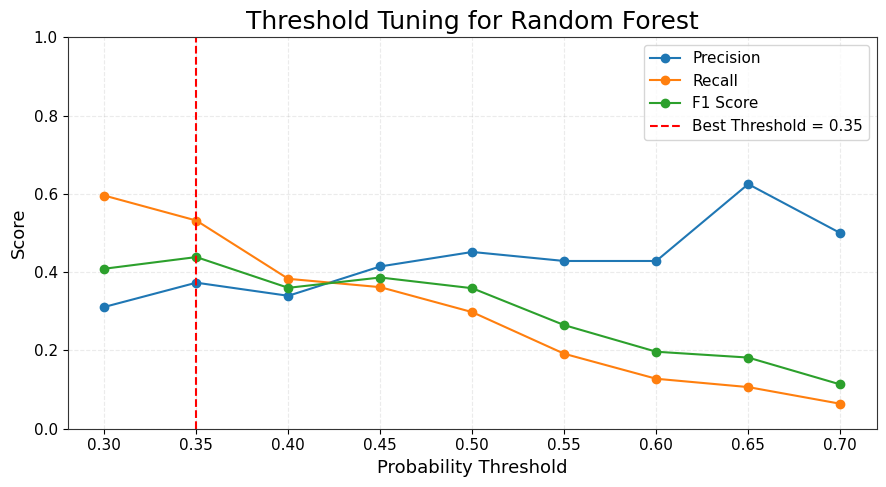

Comparison: default threshold vs best threshold
           Tuned RF @ 0.50  Tuned RF @ 0.35  Difference
Accuracy            0.8333           0.7823     -0.0510
F1 Score            0.3636           0.4386      0.0750
Precision           0.4667           0.3731     -0.0935
Recall              0.2979           0.5319      0.2340
ROC-AUC             0.7495           0.7495      0.0000
PR-AUC              0.3704           0.3704      0.0000


In [41]:
# Plot threshold tuning results
plt.figure(figsize=(9, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1 Score'], marker='o', label='F1 Score')
plt.axvline(best_threshold, linestyle='--', color='red', label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning for Random Forest')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_threshold_tuning.png'), dpi=300, bbox_inches='tight')
plt.show()

# Compare default threshold and best threshold results
threshold_comparison_df = pd.DataFrame({
    'Tuned RF @ 0.50': tuned_metrics,
    f'Tuned RF @ {best_threshold:.2f}': threshold_metrics
})
threshold_comparison_df['Difference'] = (
    threshold_comparison_df[f'Tuned RF @ {best_threshold:.2f}'] - threshold_comparison_df['Tuned RF @ 0.50']
)

print('Comparison: default threshold vs best threshold')
print(threshold_comparison_df.round(4).to_string())


## Step 14 — Confusion Matrix

A confusion matrix shows:
- true negatives
- false positives
- false negatives
- true positives

This makes it easier to understand the types of prediction errors.


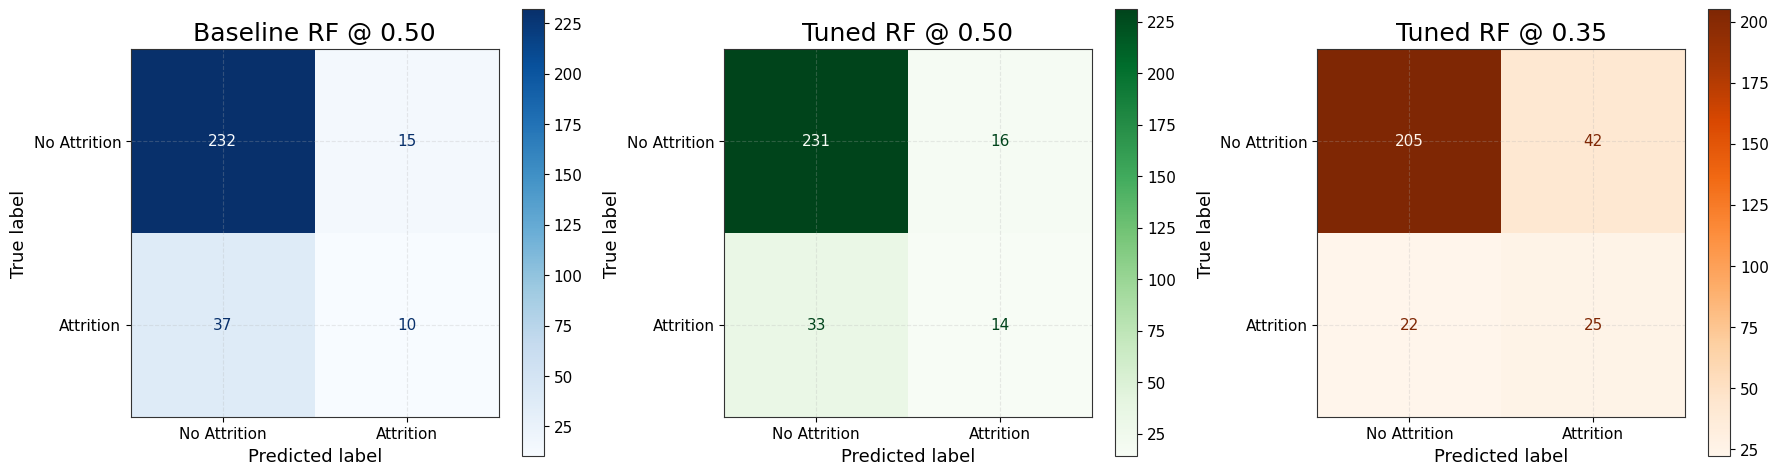

Tuned RF @ 0.50 confusion matrix values:
  True Negatives  (TN): 231
  False Positives (FP): 16
  False Negatives (FN): 33
  True Positives  (TP): 14
Tuned RF @ 0.35 confusion matrix values:
  True Negatives  (TN): 205
  False Positives (FP): 42
  False Negatives (FN): 22
  True Positives  (TP): 25


In [42]:
# Plot confusion matrices for three model settings
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, baseline_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Baseline RF @ 0.50')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=axes[1]
)
axes[1].set_title('Tuned RF @ 0.50')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best_threshold,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title(f'Tuned RF @ {best_threshold:.2f}')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print the tuned confusion matrix values
cm_default = confusion_matrix(y_test, y_pred)
cm_best = confusion_matrix(y_test, y_pred_best_threshold)

tn, fp, fn, tp = cm_default.ravel()
print('Tuned RF @ 0.50 confusion matrix values:')
print(f'  True Negatives  (TN): {tn}')
print(f'  False Positives (FP): {fp}')
print(f'  False Negatives (FN): {fn}')
print(f'  True Positives  (TP): {tp}')

tn_b, fp_b, fn_b, tp_b = cm_best.ravel()
print(f'Tuned RF @ {best_threshold:.2f} confusion matrix values:')
print(f'  True Negatives  (TN): {tn_b}')
print(f'  False Positives (FP): {fp_b}')
print(f'  False Negatives (FN): {fn_b}')
print(f'  True Positives  (TP): {tp_b}')


## Step 15 — Cross-Validation Stability Check

This checks whether the tuned model is stable across different folds of the training data.
A smaller standard deviation usually means the model is more consistent.


Cross-validation F1 scores: [np.float64(0.9476), np.float64(0.9388), np.float64(0.8997), np.float64(0.9186), np.float64(0.9282)]
Mean F1 score           : 0.9266
Standard deviation      : 0.0166


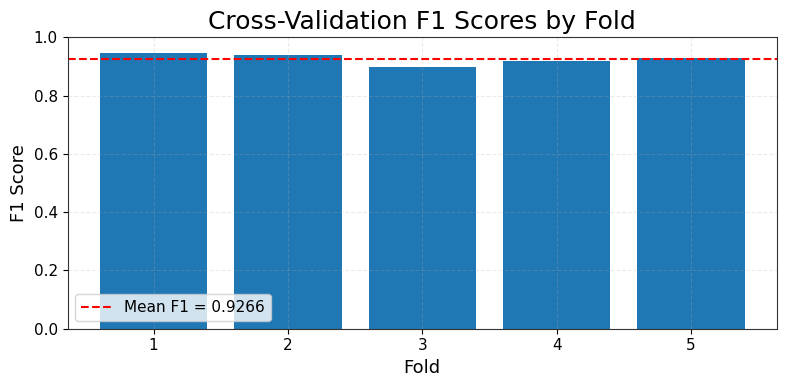

In [43]:
# Evaluate the tuned model with 5-fold cross-validation using F1 score
cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print('Cross-validation F1 scores:', [round(score, 4) for score in cv_scores])
print('Mean F1 score           :', round(cv_scores.mean(), 4))
print('Standard deviation      :', round(cv_scores.std(), 4))

# Plot fold-by-fold CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean F1 = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('Cross-Validation F1 Scores by Fold')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_cv_f1_scores.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 16 — ROC Curve

The ROC curve shows how well the model separates the two classes across many thresholds.


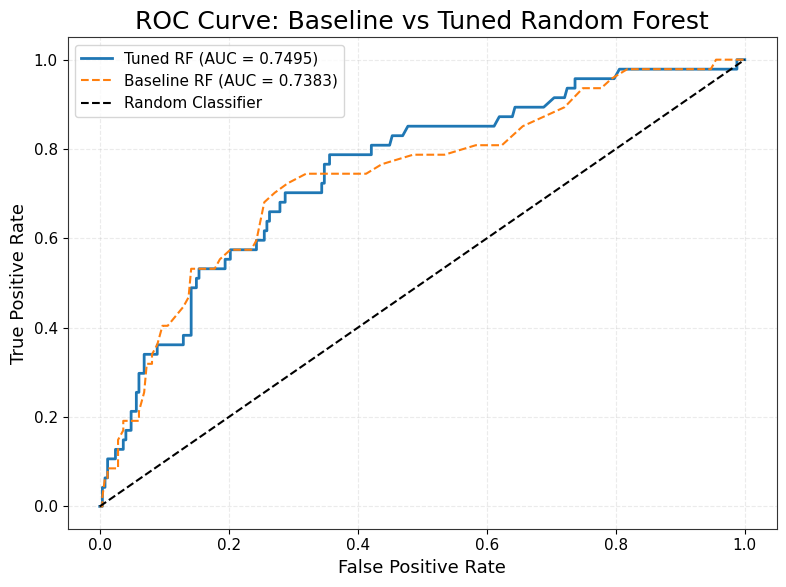

In [44]:
# Compute ROC values for tuned and baseline models
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

fpr_b, tpr_b, _ = roc_curve(y_test, baseline_prob)
roc_auc_b = roc_auc_score(y_test, baseline_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Tuned RF (AUC = {roc_auc:.4f})', linewidth=2)
plt.plot(fpr_b, tpr_b, label=f'Baseline RF (AUC = {roc_auc_b:.4f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Baseline vs Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_roc_curve.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 17 — Precision-Recall Curve

This curve is especially helpful for imbalanced classification because it focuses more on the positive class.


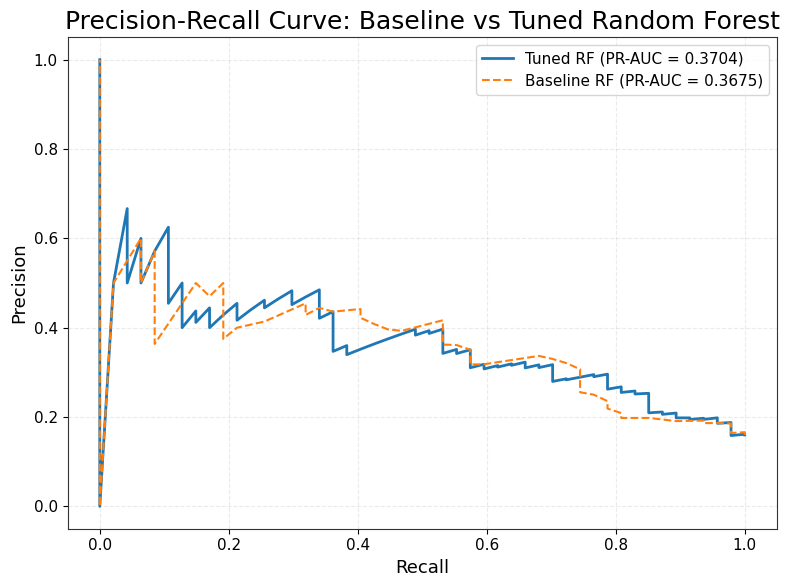

In [45]:
# Compute Precision-Recall values for tuned and baseline models
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

precision_b, recall_b, _ = precision_recall_curve(y_test, baseline_prob)
pr_auc_b = average_precision_score(y_test, baseline_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label=f'Tuned RF (PR-AUC = {pr_auc:.4f})', linewidth=2)
plt.plot(recall_b, precision_b, label=f'Baseline RF (PR-AUC = {pr_auc_b:.4f})', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Baseline vs Tuned Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_precision_recall_curve.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 18 — Feature Importance Table

Random Forest can show which features contributed most to the predictions.
This helps explain the model in a simple way.


In [46]:
# Build and sort the feature importance table
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print('Top 10 most important features:')
print(importance.head(10).to_string(index=False))


Top 10 most important features:
                Feature  Importance
       StockOptionLevel    0.071263
          MonthlyIncome    0.054023
        JobSatisfaction    0.051010
  MaritalStatus_Married    0.047516
EnvironmentSatisfaction    0.042217
   YearsWithCurrManager    0.042148
                    Age    0.040500
         JobInvolvement    0.037431
               JobLevel    0.037377
            MonthlyRate    0.037147


## Step 19 — Plot Feature Importance

This chart shows the top features that influenced the Random Forest model the most.


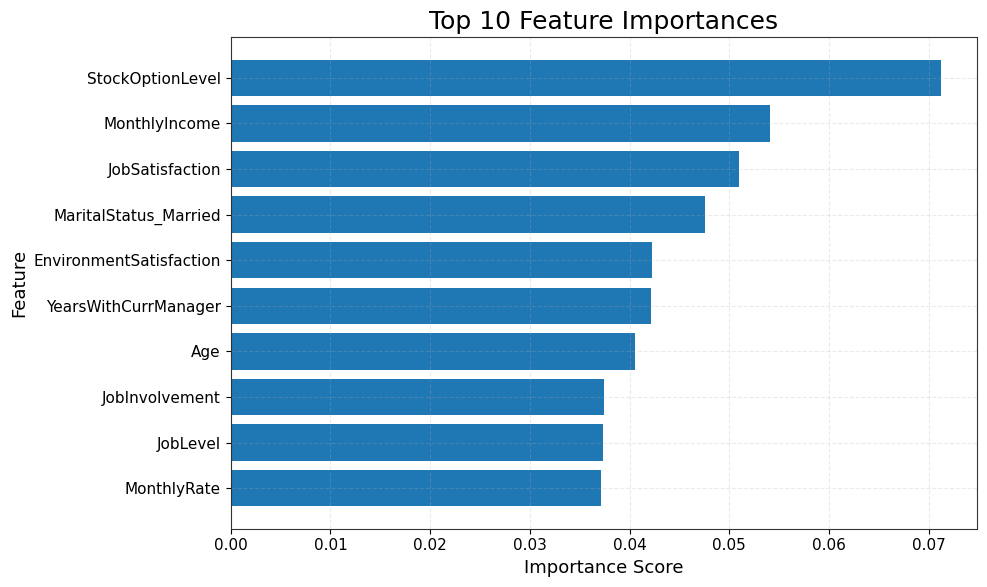

In [49]:
# Plot the top 10 most important features
top_importance = importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_importance['Feature'][::-1], top_importance['Importance'][::-1])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_top_feature_importances.png'), dpi=300, bbox_inches='tight')
plt.show()


## Step 20 — Save Prediction Files

This section saves prediction-related CSV files inside the `predictions` folder.


In [48]:
# Save prediction-related outputs
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_0.50': y_pred,
    f'Predicted_{best_threshold:.2f}': y_pred_best_threshold,
    'Probability_Attrition_1': y_prob
})

predictions_file = os.path.join(PREDICTIONS_DIR, 'random_forest_predictions.csv')
threshold_file = os.path.join(PREDICTIONS_DIR, 'random_forest_threshold_tuning_metrics.csv')

predictions_df.to_csv(predictions_file, index=False)
threshold_df.to_csv(threshold_file, index=False)

print('Saved prediction file:', predictions_file)
print('Saved threshold metrics file:', threshold_file)
print('Prediction table shape:', predictions_df.shape)


Saved prediction file: ../../outputs\predictions\random_forest_predictions.csv
Saved threshold metrics file: ../../outputs\predictions\random_forest_threshold_tuning_metrics.csv
Prediction table shape: (294, 4)


## Step 21 — Save Metric Tables

This section saves reusable metric tables and feature importance values inside the `metrics` folder.


In [50]:
# Save feature importance and performance comparison tables
feature_importance_file = os.path.join(METRICS_DIR, 'random_forest_feature_importances.csv')
comparison_file = os.path.join(METRICS_DIR, 'random_forest_model_comparison.csv')
threshold_comparison_file = os.path.join(METRICS_DIR, 'random_forest_threshold_comparison.csv')
variance_file = os.path.join(METRICS_DIR, 'random_forest_feature_variance.csv')

importance.to_csv(feature_importance_file, index=False)
comparison_df.round(6).to_csv(comparison_file)
threshold_comparison_df.round(6).to_csv(threshold_comparison_file)
variance_df.to_csv(variance_file, index=False)

print('Saved feature importances:', feature_importance_file)
print('Saved baseline vs tuned comparison:', comparison_file)
print('Saved threshold comparison:', threshold_comparison_file)
print('Saved feature variance table:', variance_file)


Saved feature importances: ../../outputs\metrics\random_forest_feature_importances.csv
Saved baseline vs tuned comparison: ../../outputs\metrics\random_forest_model_comparison.csv
Saved threshold comparison: ../../outputs\metrics\random_forest_threshold_comparison.csv
Saved feature variance table: ../../outputs\metrics\random_forest_feature_variance.csv


## Step 22 — Save the Final Tuned Model

The best tuned Random Forest model is saved inside the `models` folder.

To make reuse easier, this notebook saves:
- the trained model
- the best threshold
- the feature names
- the best hyperparameters


In [51]:
# Save the final tuned model and useful metadata
model_bundle = {
    'model': best_rf,
    'best_threshold': best_threshold,
    'feature_names': X_train.columns.tolist(),
    'best_params': grid_search.best_params_
}

model_file = os.path.join(MODELS_DIR, 'random_forest_best_model.pkl')
joblib.dump(model_bundle, model_file)

print('Saved final tuned model bundle:', model_file)


Saved final tuned model bundle: ../../outputs\models\random_forest_best_model.pkl


## Step 23 — Final Summary

This final section prints the most important results in one place.


In [52]:
# Print a simple final summary
print('=' * 70)
print('FINAL RESULTS SUMMARY — EMPLOYEE ATTRITION PREDICTION')
print('=' * 70)

print('Main evaluation metric used: F1 Score')
print('Reason: F1 balances precision and recall for attrition prediction.')

print('Best hyperparameters:')
for param, value in grid_search.best_params_.items():
    print(f'  {param:20s}: {value}')

print('Baseline vs tuned model comparison:')
print(comparison_df.round(4).to_string())

print(f'Best threshold selected by F1 score: {best_threshold:.2f}')
print('Default threshold vs best threshold comparison:')
print(threshold_comparison_df.round(4).to_string())

print('Files saved in organized folders:')
print('Models folder:')
print('  -', model_file)
print('Predictions folder:')
print('  -', predictions_file)
print('  -', threshold_file)
print('Metrics folder:')
print('  -', feature_importance_file)
print('  -', comparison_file)
print('  -', threshold_comparison_file)
print('  -', variance_file)
print('Plots folder: saved chart image files')


FINAL RESULTS SUMMARY — EMPLOYEE ATTRITION PREDICTION
Main evaluation metric used: F1 Score
Reason: F1 balances precision and recall for attrition prediction.
Best hyperparameters:
  class_weight        : balanced
  max_depth           : 15
  max_features        : sqrt
  min_samples_leaf    : 1
  min_samples_split   : 2
  n_estimators        : 300
Baseline vs tuned model comparison:
           Baseline (Default RF)  Tuned (GridSearchCV)  Improvement
Accuracy                  0.8231                0.8333       0.0102
F1 Score                  0.2778                0.3636       0.0859
Precision                 0.4000                0.4667       0.0667
Recall                    0.2128                0.2979       0.0851
ROC-AUC                   0.7383                0.7495       0.0112
PR-AUC                    0.3675                0.3704       0.0029
Best threshold selected by F1 score: 0.35
Default threshold vs best threshold comparison:
           Tuned RF @ 0.50  Tuned RF @ 0.35  Dif